# 06. 数値解法 — Euler・Heun・RK4・安定性・stiff

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 誤差と次数 〜 8. solve_ivp |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

ほとんどの ODE は閉じた式で解けません。そこで **方向場に沿って小さく前進** します。
刻み幅 $\Delta t$ をどう使うかで精度と安定性が決まります。本章は Euler / Heun / RK4 を比較し、
**「刻み方を間違えると数値解は壊れる」** ことを体験します。

## 2. Definition — 3 つのステッパ

1 ステップ $t_k \to t_{k+1}=t_k+\Delta t$ の進め方:

- **Euler(1 次)**: $y_{k+1} = y_k + \Delta t\, f(t_k, y_k)$
- **Heun(2 次)**: 予測子 + 修正子(台形)
- **RK4(4 次)**: 区間内 4 点の傾きを加重平均(精度の定番)

次数 $p$ が高いほど、$\Delta t$ を半分にしたときの誤差の減りが速い($\propto \Delta t^p$)。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 4. Visualization — 同じ $\Delta t$ でどれだけ違うか

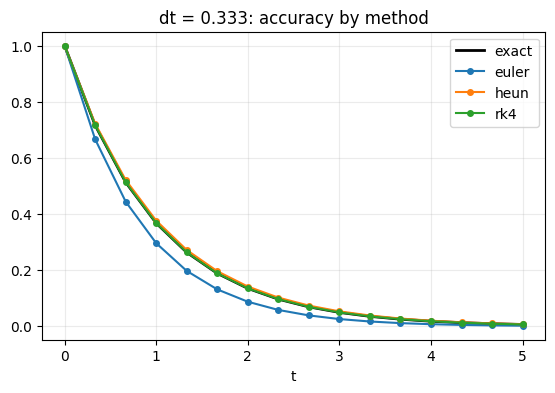

In [3]:
import numpy as np

# Same coarse dt, three methods, against the exact decay.
f = systems.exponential(-1.0)
t = np.linspace(0, 5, 16)
exact = np.exp(-t)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, exact, "k-", lw=2, label="exact")
for name, Y in [("euler", solvers.euler(f, [1.0], t)),
                ("heun", solvers.heun(f, [1.0], t)),
                ("rk4", solvers.rk4(f, [1.0], t))]:
    ax.plot(t, Y[:, 0], "o-", ms=4, label=name)
ax.legend()
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title(f"dt = {t[1] - t[0]:.3f}: accuracy by method")
plt.show()

## 5. 誤差と収束次数 (Applied)

刻み幅 $\Delta t$ に対する最大誤差を両対数で見ると、傾きが **収束次数** を表します
(Euler ≈ 1、Heun ≈ 2、RK4 ≈ 4)。

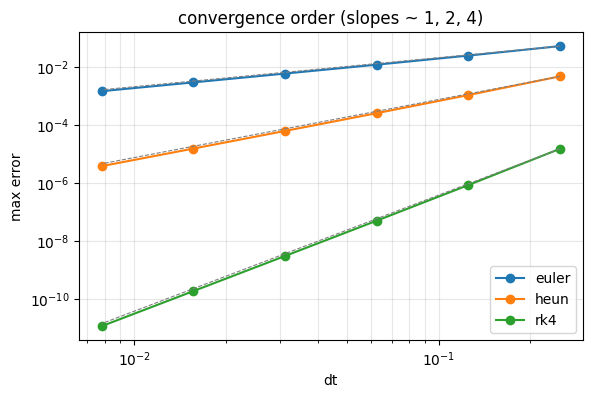

euler  measured order ~ 1.03
heun   measured order ~ 2.05
rk4    measured order ~ 4.06


In [4]:
import numpy as np

# Convergence order: error vs dt on log-log; slope = method order.
f = systems.exponential(-1.0)
ns = np.array([8, 16, 32, 64, 128, 256])
dts, errs = [], {"euler": [], "heun": [], "rk4": []}
for n in ns:
    t = np.linspace(0, 2, n + 1)
    dts.append(t[1] - t[0])
    exact = np.exp(-t)
    for name, fn in [("euler", solvers.euler), ("heun", solvers.heun), ("rk4", solvers.rk4)]:
        errs[name].append(solvers.global_error(fn(f, [1.0], t)[:, 0], exact))

fig, ax = plt.subplots(figsize=(6.5, 4))
for name in errs:
    ax.loglog(dts, errs[name], "o-", label=name)
for p, c in [(1, "1"), (2, "2"), (4, "4")]:
    ref = np.array(dts) ** p
    ax.loglog(dts, ref / ref[0] * errs["euler" if p == 1 else "heun" if p == 2 else "rk4"][0],
              "--", color="gray", lw=0.8)
ax.legend()
ax.set_xlabel("dt")
ax.set_ylabel("max error")
ax.set_title("convergence order (slopes ~ 1, 2, 4)")
ax.grid(alpha=0.3, which="both")
plt.show()
for name in errs:
    rate = np.log(errs[name][0] / errs[name][-1]) / np.log(dts[0] / dts[-1])
    print(f"{name:6s} measured order ~ {rate:.2f}")

## 6. 安定性 — 大きすぎる $\Delta t$ で爆発する

精度とは別に **安定性** の問題があります。$dy/dt=\lambda y$($\lambda<0$)に陽的 Euler を使うと、
増幅率は $|1+\lambda\Delta t|$。これが 1 を超える($\Delta t > 2/|\lambda|$)と、真の解は減衰するのに
**数値解は振動しながら発散** します。

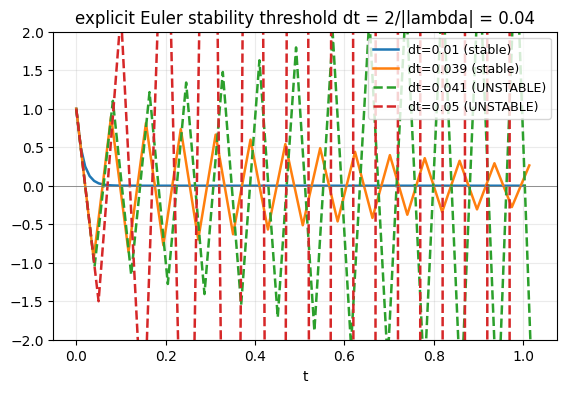

In [5]:
import numpy as np

# Explicit Euler on dy/dt = -50 y: stable only if dt < 2/50 = 0.04.
lam = -50.0
f = systems.exponential(lam)
fig, ax = plt.subplots(figsize=(6.5, 4))
for dt in (0.01, 0.039, 0.041, 0.05):
    t = np.arange(0, 1 + dt, dt)
    Y = solvers.euler(f, [1.0], t)[:, 0]
    style = "-" if dt < 2 / abs(lam) else "--"
    ax.plot(t, Y, style, lw=1.8, label=f"dt={dt} ({'stable' if dt < 0.04 else 'UNSTABLE'})")
ax.axhline(0, color="gray", lw=0.6)
ax.set_ylim(-2, 2)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlabel("t")
ax.set_title("explicit Euler stability threshold dt = 2/|lambda| = 0.04")
plt.show()

## 7. stiff 方程式 — 陰解法の出番

**stiff** な系は、速い成分と遅い成分の時間スケールが極端に違う系です。
陽的解法は安定性のために極小の $\Delta t$ を強いられ、非効率。**陰的解法**(Radau, BDF)は
大きな刻みでも安定です。固有値 $-1$ と $-1000$ を持つ線形系で、関数評価回数 (`nfev`) を比べます。

In [6]:
import numpy as np
from scipy.integrate import solve_ivp

# Stiff linear system: eigenvalues -1 and -1000. Compare explicit RK45 vs implicit Radau.
A = np.array([[-1.0, 0.0], [0.0, -1000.0]])
f = systems.linear_system(A)
span = (0.0, 5.0)
y0 = [1.0, 1.0]
for method in ("RK45", "Radau", "BDF"):
    sol = solve_ivp(f, span, y0, method=method, rtol=1e-6, atol=1e-9)
    print(f"{method:6s}  steps(nfev) = {sol.nfev:6d}   success = {sol.success}")

RK45    steps(nfev) =  10796   success = True
Radau   steps(nfev) =   1022   success = True
BDF     steps(nfev) =    406   success = True


## 8. `scipy.integrate.solve_ivp` — 実務の道具

手作りステッパは学習用。実務では適応刻み幅・誤差制御つきの `solve_ivp` を使います。
`solvers.solve` はその薄いラッパで、グリッド上の解を返します(stiff なら `method="Radau"`)。

## Exercises

1. Heun 法の収束次数が 2 であることを、上の収束プロットの傾きから読み取れ。
2. 陽的 Euler の安定限界 $\Delta t < 2/|\lambda|$ を、増幅率 $|1+\lambda\Delta t|<1$ から導け。
3. stiff 系で RK45 と Radau の `nfev` 比を確かめ、なぜ陰解法が有利か説明せよ。

## Advanced Notes

- **絶対安定領域**: 各解法には複素平面上の安定領域がある。陽的法は有界、陰的法(A-安定)は左半平面全体を含む。
- **適応刻み**: RK45(Dormand–Prince)は 4 次と 5 次の差で誤差を推定し $\Delta t$ を自動調整する。
- **保存系の長時間積分**: シンプレクティック法は位相空間体積を保ち、エネルギー誤差が増えない。
- **DAE / イベント検出**: `solve_ivp` の `events` で「地面に着いた瞬間」などを検出できる。